# Wholesale Customers Statistical Analysis

## Purpose

This notebook answers three simple research questions:

1. Do male and female participants differ in **stress level**?
2. Do participants with and without a sleep disorder differ in **sleep duration**?
3. Do participants with insomnia and sleep apnea differ in **physical activity level**?

Because each question compares **two independent groups**, the possible method is either an independent-samples t-test or a non-parametric alternative.  
Before testing the questions, we first check whether the compared outcomes behave like normally distributed data.

### Statistical decision rule

- Significance level: **α = 0.05**
- When the group distributions are non-normal or clearly skewed, we use the **Mann–Whitney U test**
- Since each scenario has only **two groups**, no post-hoc test is needed
- Levene's test is not required once we choose Mann–Whitney U, because it is used when deciding how to handle unequal variances in a t-test


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, skew, mannwhitneyu

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Load and understand the dataset

In [2]:
# The notebook works when the CSV is beside the notebook
# or inside a data folder in a project.

try:
    df = pd.read_csv("sleep.csv")
except FileNotFoundError:
    df = pd.read_csv("../data/sleep.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1000,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2000,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2000,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9000,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))

Columns:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Missing values:


,Missing Values
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


## 2. Prepare the sleep disorder groups

The original `Sleep Disorder` column uses missing values for participants who do not have a listed disorder.  
We create:

- `Sleep Disorder Filled`: keeps the three readable categories: None, Insomnia, Sleep Apnea
- `Has Sleep Disorder`: simplifies the variable into No versus Yes for Scenario 2


In [4]:
df["Sleep Disorder Filled"] = df["Sleep Disorder"].fillna("None")

df["Has Sleep Disorder"] = np.where(
    df["Sleep Disorder"].isna(),
    "No",
    "Yes"
)

display(df["Sleep Disorder Filled"].value_counts().to_frame("Count"))
display(df["Has Sleep Disorder"].value_counts().to_frame("Count"))

,Count
Sleep Disorder Filled,
None,219
Sleep Apnea,78
Insomnia,77


,Count
Has Sleep Disorder,
No,219
Yes,155


## 3. Define the three research questions

In [5]:
scenarios = [
    {
        "Question": "Do male and female participants differ in stress level?",
        "Group Column": "Gender",
        "Group 1": "Male",
        "Group 2": "Female",
        "Outcome": "Stress Level"
    },
    {
        "Question": "Do participants with and without sleep disorders differ in sleep duration?",
        "Group Column": "Has Sleep Disorder",
        "Group 1": "No",
        "Group 2": "Yes",
        "Outcome": "Sleep Duration"
    },
    {
        "Question": "Do insomnia and sleep apnea participants differ in physical activity level?",
        "Group Column": "Sleep Disorder Filled",
        "Group 1": "Insomnia",
        "Group 2": "Sleep Apnea",
        "Outcome": "Physical Activity Level"
    }
]

display(pd.DataFrame(scenarios))

,Question,Group Column,Group 1,Group 2,Outcome
0,Do male and female participants differ in stre...,Gender,Male,Female,Stress Level
1,Do participants with and without sleep disorde...,Has Sleep Disorder,No,Yes,Sleep Duration
2,Do insomnia and sleep apnea participants diffe...,Sleep Disorder Filled,Insomnia,Sleep Apnea,Physical Activity Level


## 4. Check distributions before choosing the test

For each comparison, we examine:

- **Skewness**: values far from 0 suggest an asymmetric distribution
- **Shapiro–Wilk test**: when `p < 0.05`, normality is rejected
- **Histograms and boxplots**: visual evidence of shape and possible outliers

The test choice is based on the evidence below, not selected automatically without checking.


In [6]:
normality_rows = []

for scenario in scenarios:
    for group in [scenario["Group 1"], scenario["Group 2"]]:
        values = df.loc[
            df[scenario["Group Column"]] == group,
            scenario["Outcome"]
        ].dropna()

        shapiro_result = shapiro(values)

        normality_rows.append({
            "Outcome": scenario["Outcome"],
            "Group": group,
            "N": len(values),
            "Median": values.median(),
            "Mean": values.mean(),
            "Skewness": skew(values, bias=False),
            "Shapiro W": shapiro_result.statistic,
            "p-value": shapiro_result.pvalue,
            "Normal at α = 0.05?": "Yes" if shapiro_result.pvalue >= 0.05 else "No"
        })

normality_table = pd.DataFrame(normality_rows)
display(normality_table.round(4))

,Outcome,Group,N,Median,Mean,Skewness,Shapiro W,p-value,Normal at α = 0.05?
0,Stress Level,Male,189,6.0000,6.0794,0.0128,0.8976,0.0000,No
1,Stress Level,Female,185,4.0000,4.6757,0.8544,0.7537,0.0000,No
2,Sleep Duration,No,219,7.4000,7.3584,-0.4315,0.9231,0.0000,No
3,Sleep Duration,Yes,155,6.5000,6.8123,0.7842,0.8325,0.0000,No
4,Physical Activity Level,Insomnia,77,45.0000,46.8182,2.5829,0.5448,0.0000,No
5,Physical Activity Level,Sleep Apnea,78,75.0000,74.7949,-1.3403,0.7578,0.0000,No


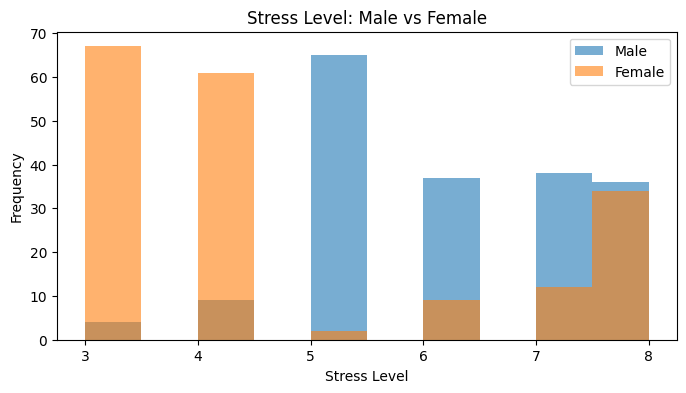

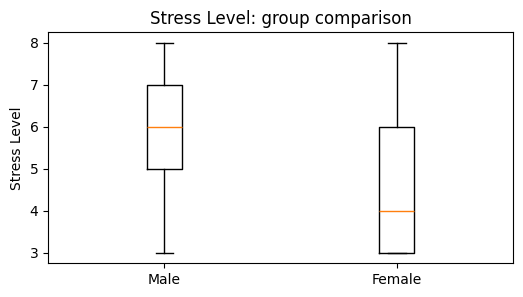

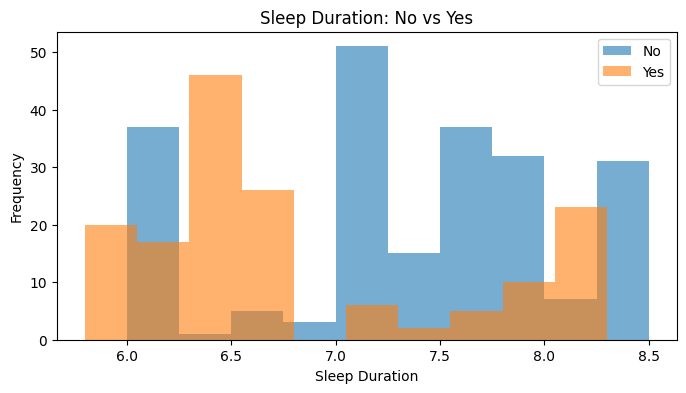

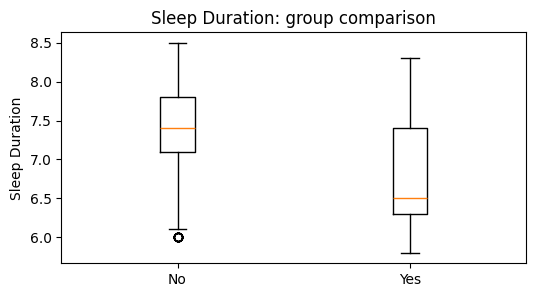

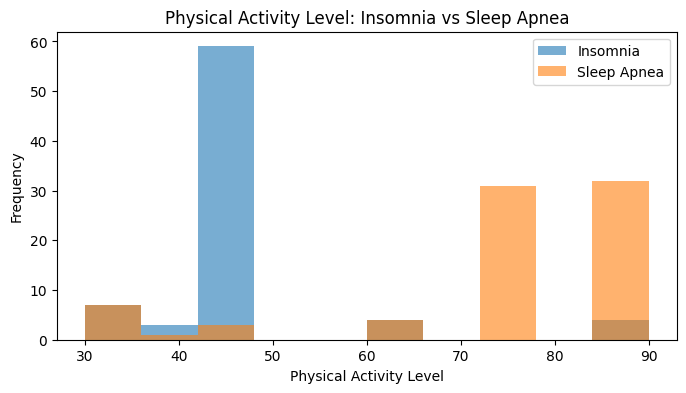

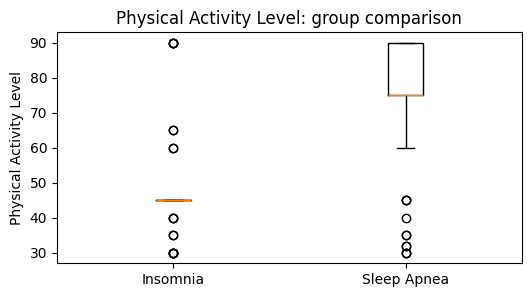

In [7]:
for scenario in scenarios:
    group_col = scenario["Group Column"]
    outcome = scenario["Outcome"]
    group_1 = scenario["Group 1"]
    group_2 = scenario["Group 2"]

    x = df.loc[df[group_col] == group_1, outcome].dropna()
    y = df.loc[df[group_col] == group_2, outcome].dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(x, bins=10, alpha=0.6, label=group_1)
    plt.hist(y, bins=10, alpha=0.6, label=group_2)
    plt.title(f"{outcome}: {group_1} vs {group_2}")
    plt.xlabel(outcome)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.boxplot([x, y], tick_labels=[group_1, group_2])
    plt.title(f"{outcome}: group comparison")
    plt.ylabel(outcome)
    plt.show()

### Method choice

The Shapiro–Wilk results show `p < 0.05` for the distributions used in all three comparisons. The plots also help us see the non-normal or uneven shapes of the data.

Therefore, the appropriate method for all three research questions is the **Mann–Whitney U test**, which compares two independent groups without requiring normal distribution.

Because every comparison contains only two groups:

- **Dunn post-hoc testing is not needed**
- **Levene's variance test is not needed for the chosen non-parametric test**


## 5. Apply the Mann–Whitney U test

### Effect size used: rank-biserial correlation

A p-value tells us whether the group difference is statistically significant.  
The effect size tells us how strong the difference is.

Interpretation of the absolute effect size:

- Less than 0.30: small
- 0.30 to less than 0.50: moderate
- 0.50 or above: large

For the direction:

- Positive value: Group 1 generally has higher scores
- Negative value: Group 2 generally has higher scores


In [8]:
def effect_size_label(value):
    absolute_value = abs(value)

    if absolute_value < 0.30:
        return "Small"
    elif absolute_value < 0.50:
        return "Moderate"
    else:
        return "Large"


def run_mann_whitney(data, scenario):
    group_col = scenario["Group Column"]
    group_1 = scenario["Group 1"]
    group_2 = scenario["Group 2"]
    outcome = scenario["Outcome"]

    x = data.loc[data[group_col] == group_1, outcome].dropna()
    y = data.loc[data[group_col] == group_2, outcome].dropna()

    test = mannwhitneyu(
        x,
        y,
        alternative="two-sided",
        method="asymptotic"
    )

    rank_biserial = (2 * test.statistic / (len(x) * len(y))) - 1

    return {
        "Question": scenario["Question"],
        "Outcome": outcome,
        "Group 1": group_1,
        "N1": len(x),
        "Median 1": x.median(),
        "Group 2": group_2,
        "N2": len(y),
        "Median 2": y.median(),
        "U Statistic": test.statistic,
        "p-value": test.pvalue,
        "Significant?": "Yes" if test.pvalue < 0.05 else "No",
        "Rank-Biserial r": rank_biserial,
        "Effect Size": effect_size_label(rank_biserial)
    }

In [9]:
results = []

for scenario in scenarios:
    results.append(run_mann_whitney(df, scenario))

results_table = pd.DataFrame(results)

display(
    results_table[
        [
            "Outcome", "Group 1", "N1", "Median 1",
            "Group 2", "N2", "Median 2",
            "U Statistic", "p-value", "Significant?",
            "Rank-Biserial r", "Effect Size"
        ]
    ].round(4)
)

,Outcome,Group 1,N1,Median 1,Group 2,N2,Median 2,U Statistic,p-value,Significant?,Rank-Biserial r,Effect Size
0,Stress Level,Male,189,6.0000,Female,185,4.0000,25931.0000,0.0000,Yes,0.4833,Moderate
1,Sleep Duration,No,219,7.4000,Yes,155,6.5000,23039.0000,0.0000,Yes,0.3574,Moderate
2,Physical Activity Level,Insomnia,77,45.0000,Sleep Apnea,78,75.0000,910.5000,0.0000,Yes,-0.6968,Large


## 6. Plain-language interpretation of the results

In [10]:
alpha = 0.05

for number, result in enumerate(results, start=1):
    p_value = result["p-value"]
    r_value = result["Rank-Biserial r"]

    print(f"Scenario {number}: {result['Question']}")
    print(
        f"{result['Group 1']} median = {result['Median 1']}; "
        f"{result['Group 2']} median = {result['Median 2']}."
    )
    print(f"U = {result['U Statistic']:.2f}, p = {p_value:.6f}.")

    if p_value < alpha:
        higher_group = result["Group 1"] if r_value > 0 else result["Group 2"]
        print(
            f"There is a statistically significant difference. "
            f"{higher_group} generally shows higher values on {result['Outcome']}."
        )
        print(
            f"The effect size is {result['Effect Size'].lower()} "
            f"(rank-biserial r = {r_value:.3f})."
        )
    else:
        print("There is no statistically significant difference between the two groups.")

    print()

Scenario 1: Do male and female participants differ in stress level?
Male median = 6.0; Female median = 4.0.
U = 25931.00, p = 0.000000.
There is a statistically significant difference. Male generally shows higher values on Stress Level.
The effect size is moderate (rank-biserial r = 0.483).

Scenario 2: Do participants with and without sleep disorders differ in sleep duration?
No median = 7.4; Yes median = 6.5.
U = 23039.00, p = 0.000000.
There is a statistically significant difference. No generally shows higher values on Sleep Duration.
The effect size is moderate (rank-biserial r = 0.357).

Scenario 3: Do insomnia and sleep apnea participants differ in physical activity level?
Insomnia median = 45.0; Sleep Apnea median = 75.0.
U = 910.50, p = 0.000000.
There is a statistically significant difference. Sleep Apnea generally shows higher values on Physical Activity Level.
The effect size is large (rank-biserial r = -0.697).



## 7. Final summary

This analysis began by checking the distribution of each outcome inside the groups being compared.  
Since the Shapiro–Wilk results rejected normality in all compared distributions and the visual plots supported a non-parametric approach, **Mann–Whitney U** was applied in all three scenarios.

The notebook reports:

- Group sizes and medians
- Normality evidence before testing
- Mann–Whitney U statistics and p-values
- Rank-biserial effect sizes
- Readable conclusions for each research question

No post-hoc testing is required because none of the analyses compares more than two groups.
